### Uniform Exploration

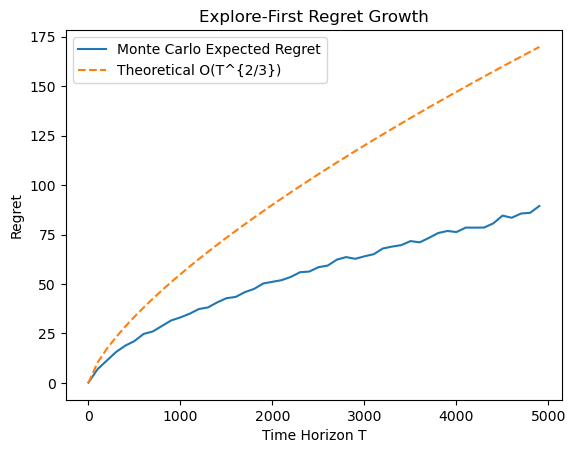

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def explore_first(mu, N, T):
    K = len(mu)
    rewards = []
    estimates = []
    for a in range(K):
        rewards_a = np.random.binomial(1, mu[a], N)
        rewards.extend(rewards_a)
        estimates.append(np.mean(rewards_a))
    #print(rewards)
    #print(estimates)
    
    best_arm = np.argmax(estimates)
    #print(best_arm)
    
    remaining = T - K * N
    if remaining > 0:
        rewards_a = np.random.binomial(1, mu[best_arm], remaining)
        rewards.extend(rewards_a)
    
    mu_star = max(mu)
    
    regret = mu_star * T - np.sum(rewards)
    return regret
    
mu = [0.4, 0.6, 0.5]
N = 20
T = 20

def expected_regret(mu, T, runs=2000):
    K = len(mu)
    N = int((T/K)**(2/3) * (np.log(T))**(1/3))
    
    regrets = []
    
    for _ in range(runs):
        regrets.append(explore_first(mu, N, T))
        
    return np.mean(regrets)


time_horizons = np.arange(1, 5001, 100)
monte_carlo_expected_regret = []
C = 0.2 

for th in time_horizons:
    monte_carlo_expected_regret.append(expected_regret(mu, th))
    
theoretical_expected_regret = C * (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


plt.plot(time_horizons, monte_carlo_expected_regret, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical O(T^{2/3})", linestyle="--")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Explore-First Regret Growth")

plt.show()